In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')


In [3]:
car_dataset = pd.read_csv('../data/Prepared/prep_model.csv')

In [4]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48050 entries, 0 to 48049
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            48050 non-null  object 
 1   model_clean      48050 non-null  object 
 2   mileage          48050 non-null  float64
 3   engine_volume_l  48050 non-null  float64
 4   fuel_type        48050 non-null  object 
 5   transmission     48050 non-null  object 
 6   body_type        48050 non-null  object 
 7   condition        48050 non-null  object 
 8   owners_count     48050 non-null  float64
 9   region           48050 non-null  object 
 10  color            48050 non-null  object 
 11  price_usd        48050 non-null  float64
 12  district         48050 non-null  object 
 13  age              48050 non-null  float64
dtypes: float64(5), object(9)
memory usage: 5.1+ MB


Text(0.5, 1.0, 'Future Corelation')

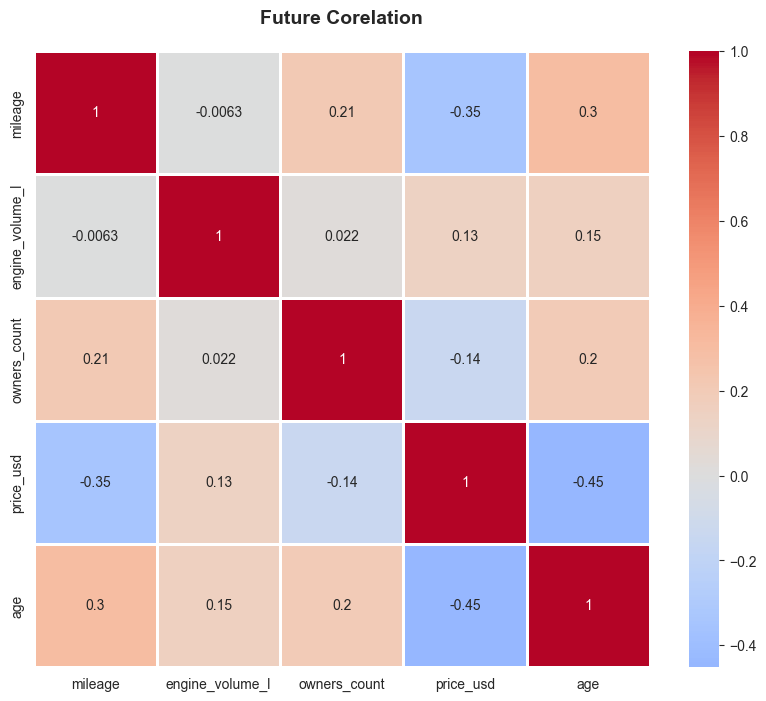

In [8]:
plt.figure(figsize = (10,8))
numeric_data = car_dataset.select_dtypes(include=[np.number])
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Future Corelation', fontsize = 14, fontweight = 'bold', pad=20)

By looking at the chart H and Price USD has a negative correlation it makes sense because when car gets older, it's price will go down generally.and there is another correlation between a price USD and mileage. It also makes sense if car use it more often mileage will go up and Priceville decrease. And another one for age in mileage, for example if car gets sold logically mileage will increase.

In [9]:
car_dataset.columns

Index(['brand', 'model_clean', 'mileage', 'engine_volume_l', 'fuel_type',
       'transmission', 'body_type', 'condition', 'owners_count', 'region',
       'color', 'price_usd', 'district', 'age'],
      dtype='object')

Text(0, 0.5, 'Price')

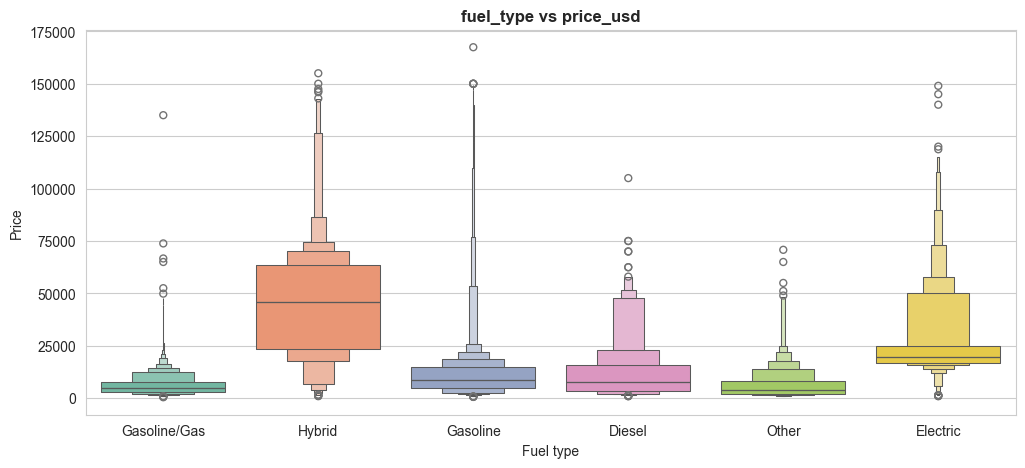

In [17]:
# fuel_type vs price_usd
plt.figure(figsize = (12,5))
sns.boxenplot(x = 'fuel_type', y='price_usd', data=car_dataset, palette='Set2')
plt.title('fuel_type vs price_usd', fontweight = 'bold')
plt.xlabel('Fuel type')
plt.ylabel('Price')

By looking at the chart, we can see gasoline with gas has the lowest median which is around 5000. Gasoline has a median around $9000. It makes sense somehow hybrid cars have the highest median which is $45,000.

In [23]:
car_dataset[car_dataset['transmission']=='Other']

,brand,model_clean,mileage,engine_volume_l,fuel_type,transmission,body_type,condition,owners_count,region,color,price_usd,district,age
31,Other,2125 Комби,24000.0,1.965,Other,Other,Other,Excellent,1.0,Karakalpakstan,White,1250.0,Tahtakupyr,36.0
368,Lada,2106,98365.0,1.100,Gasoline,Other,Other,Average,2.0,Tashkent,Red,1000.0,Zangiata,45.0
530,Volkswagen,Jetta,274931.5,1.500,Gasoline,Other,Sedan,Average,2.0,Tashkent,Red,1000.0,Yakkasaray,45.0
831,Lada,2106,98365.0,2.110,Other,Other,Sedan,Excellent,1.0,Bukhara,Gold,1333.3,Zhondor,32.0
1002,Other,Другая,24000.0,1.600,Other,Other,Other,Excellent,1.0,Navoi,Red,1200.0,Kyzyltepa,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46740,Other,GLE 450,60000.0,3.000,Other,Other,Sedan,Excellent,1.0,Tashkent,Gray,1800.0,Sergeli,4.0
46870,Other,Другая,24000.0,1.000,Gasoline/Gas,Other,Other,Good,4.0,Kashkadarya,Blue,2000.0,Karshi,44.0
46875,Lada,2106,94677.0,6.000,Gasoline/Gas,Other,Minivan,Good,4.0,Samarkand,White,2000.0,Samarkand,26.0
47230,Daewoo,Damas,179000.0,3.000,Other,Other,Other,Good,3.0,Khorezm,White,2083.3,Hiva,18.0


In [27]:
car_dataset.loc[
    (car_dataset["transmission"] == "Other") & 
    (car_dataset["fuel_type"].isin(["Electric", "Hybrid"])),
    "transmission"
] = "EV/Hybrid"

car_dataset["transmission"] = car_dataset["transmission"].replace("Other", "Unknown")

Text(0, 0.5, 'Price')

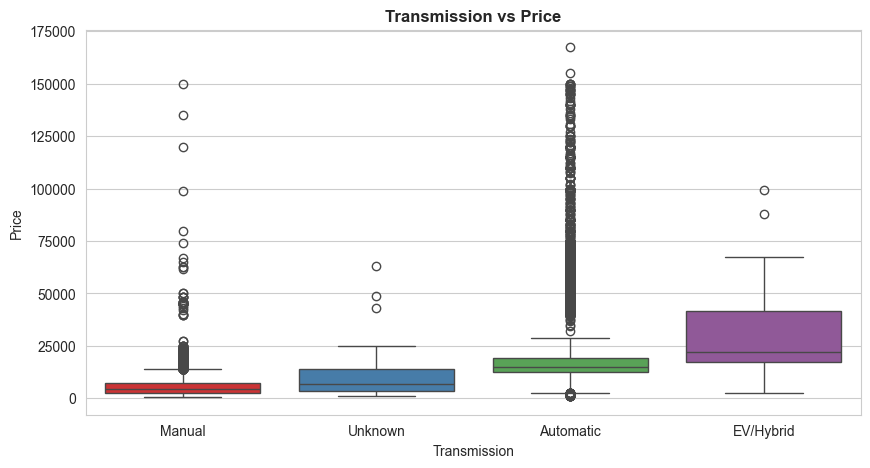

In [28]:
# Transmissions vs Price
plt.figure(figsize=(10,5))
sns.boxplot(x = 'transmission', y = 'price_usd', data=car_dataset, palette='Set1')
plt.title('Transmission vs Price', fontweight = 'bold')
plt.xlabel('Transmission')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

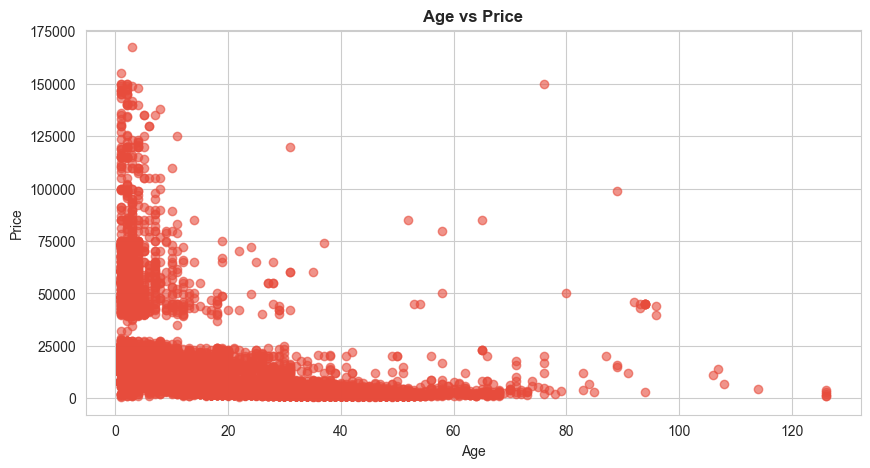

In [32]:
# age vs price
plt.figure(figsize=(10,5))
plt.scatter(car_dataset['age'], car_dataset['price_usd'], alpha=0.6, c = '#e74c3c')
plt.title('Age vs Price', fontweight = 'bold')
plt.xlabel('Age')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

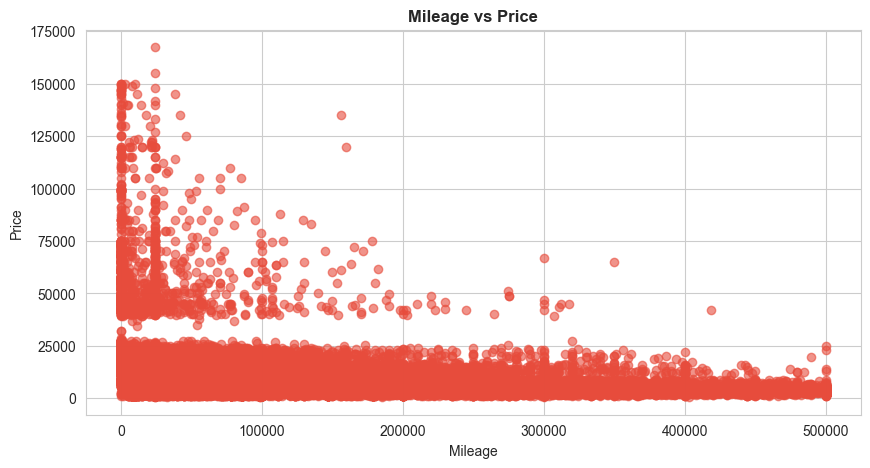

In [36]:
# mileage vs price
plt.figure(figsize=(10,5))
plt.scatter(car_dataset['mileage'], car_dataset['price_usd'], alpha=0.6, c = '#e74c3c')
plt.title('Mileage vs Price', fontweight = 'bold')
plt.xlabel('Mileage')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

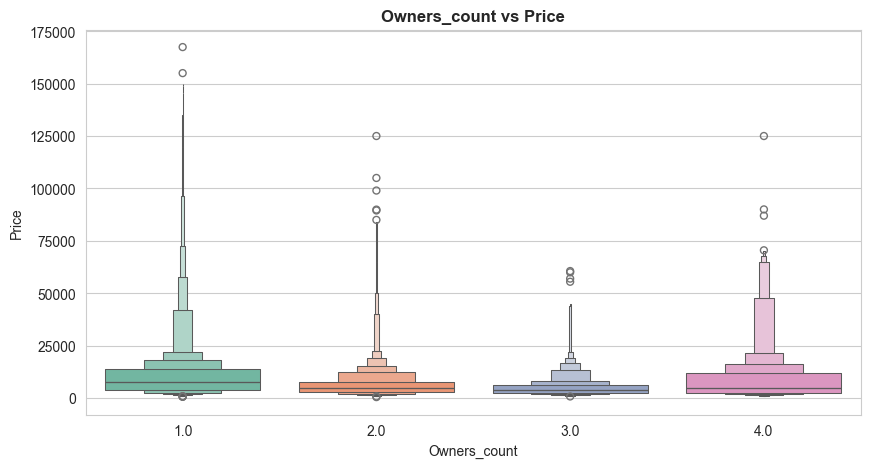

In [38]:
# Owner Count vs price
plt.figure(figsize=(10,5))
sns.boxenplot(x = 'owners_count', y='price_usd', data=car_dataset, palette='Set2')
plt.title('Owners_count vs Price', fontweight = 'bold')
plt.xlabel('Owners_count')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

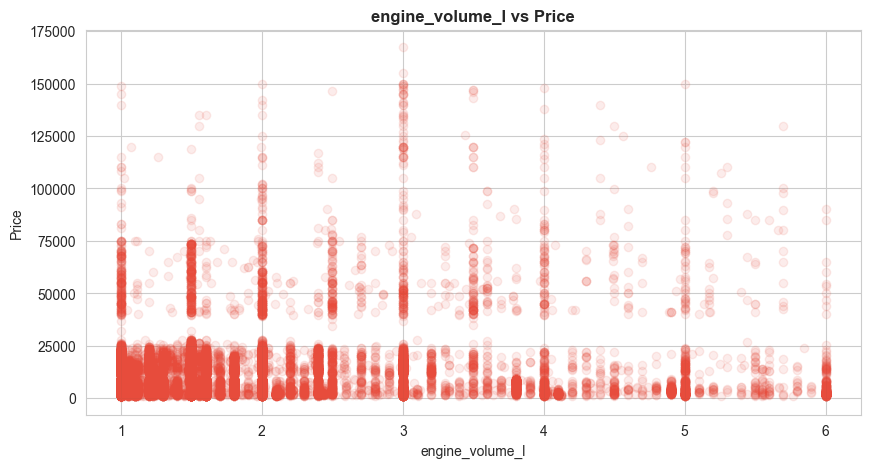

In [43]:
# engine_volume_l vs price 
plt.figure(figsize=(10,5))
plt.scatter(car_dataset['engine_volume_l'], car_dataset['price_usd'], alpha=0.1, c = '#e74c3c')
plt.title('engine_volume_l vs Price', fontweight = 'bold')
plt.xlabel('engine_volume_l')
plt.ylabel('Price')

In [ ]:
categorical_features = [
    'brand',
    'model_clean',
    'fuel_type',
    'transmission',
    'body_type',
    'condition',
    'region',
    'color',
    'district'
]

In [45]:
print(car_dataset['condition'].value_counts())

condition
Excellent       26219
Good            18028
Average          3607
Needs Repair      196
Name: count, dtype: int64


In [47]:
car_dataset.replace({'condition':{'Needs Repair': 0, 'Average':1, 'Good': 2, 'Excellent':3}},inplace=True)

In [48]:
car_dataset.head()

,brand,model_clean,mileage,engine_volume_l,fuel_type,transmission,body_type,condition,owners_count,region,color,price_usd,district,age
0,Lada,2103,98365.0,1.20,Gasoline/Gas,Manual,Sedan,2,2.0,Jizzakh,Red,1250.0,Gallaaral,47.0
1,Lada,2105,72122.0,1.00,Gasoline/Gas,Manual,Sedan,1,1.0,Namangan,Green,1250.0,Namangan,44.0
2,Lada,2101,98365.0,2.10,Gasoline/Gas,Manual,Convertible,2,4.0,Khorezm,White,1250.0,Karaul,47.0
3,GAZ,31029,147000.0,1.05,Gasoline/Gas,Manual,Station Wagon,2,2.0,Jizzakh,White,1250.0,Mardzhanbulak,30.0
4,Other,626,24000.0,1.60,Gasoline/Gas,Manual,Hatchback,0,1.0,Karakalpakstan,White,1250.0,Kungrad,40.0
